<a href="https://colab.research.google.com/github/anfeng649-png/retail_mobility_covid/blob/main/retail_mobility_covid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Asymmetric Retail Impact of COVID-19 Mobility Restrictions in Australia
### A Two-Way Fixed Effects Panel Analysis
**Ang Li | ANU Master of Economic Policy | May 2026**

---

## Abstract

This notebook investigates whether COVID-19 mobility restrictions had asymmetric
effects on retail turnover across categories with different levels of foot-traffic
dependence. Using monthly state-level data from the ABS Retail Trade survey
(Cat. 8501.0, Table 12) and Google COVID-19 Community Mobility Reports, I estimate
a two-way fixed effects panel regression across six Australian states and territories
over March 2020 to September 2022.

The key finding is that department stores were approximately 2.7 times more sensitive
to mobility variation than takeaway food services (β₂ = 0.0206, p < 0.001 under wild
cluster bootstrap), consistent with the hypothesis that non-essential,
foot-traffic-dependent categories bear a disproportionate share of mobility-induced
spending shocks. Results are robust to leave-one-out exclusions, lagged mobility
specifications, and state-category specific linear time trends.

**Data sources**: All data are pulled directly from public URLs, with no local files
required. The notebook is fully reproducible.

**Keywords**: COVID-19, retail trade, mobility restrictions, two-way fixed effects,
Australia, panel data

## 1. Data Acquisition: ABS Retail Trade

This notebook uses two data sources, both pulled directly from the web to ensure full reproducibility.

**Source 1: ABS Retail Trade, Australia (Cat. No. 8501.0), Table 12**
- Retail turnover by state and industry subgroup, seasonally adjusted, monthly
- Downloaded directly from the ABS website via `requests`, with no local file required
- Coverage: all available history (our analysis uses March 2020 to September 2022)

We first load the Excel workbook into memory and inspect the available sheets before parsing.

In [22]:
import requests
import pandas as pd
from io import BytesIO

ABS_URL = "https://www.abs.gov.au/statistics/industry/retail-and-wholesale-trade/retail-trade-australia/jun-2025/8501012.xlsx"

response = requests.get(ABS_URL, headers={"User-Agent": "Mozilla/5.0"})
print("Status code:", response.status_code)
print("Content type:", response.headers.get("Content-Type"))

Status code: 200
Content type: application/vnd.openxmlformats-officedocument.spreadsheetml.sheet



## 1.1 Inspect Workbook Structure

We load the Excel file into memory using `BytesIO` (no local download required) and inspect
the available sheets. ABS time series workbooks typically contain three sheets:
- **Index**: a lookup table mapping each series ID to its description
- **Data1**: the actual time series data (this is what we need)
- **Enquiries**: contact information, can be ignored




In [23]:
xls = pd.ExcelFile(BytesIO(response.content))
print("Available sheets:")
for sheet in xls.sheet_names:
    print(" -", sheet)

Available sheets:
 - Index
 - Data1
 - Enquiries


## 1.2 Preview Raw Data Structure

ABS time series workbooks have a non-standard layout, where the first 9 rows are metadata
(series description, units, frequency, start/end dates, series ID), and the actual
monthly observations begin from row 10 onwards. Each column represents one time series
(a unique state × industry subgroup combination).

We preview the first 10 rows and 5 columns to confirm this structure before parsing.

In [24]:
df_raw = pd.read_excel(BytesIO(response.content), sheet_name="Data1", header=None)
print(df_raw.shape)
print(df_raw.iloc[:10, :5])

(529, 190)
                  0                                                  1  \
0               NaN  Turnover ;  New South Wales ;  Supermarket and...   
1              Unit                                         $ Millions   
2       Series Type                                Seasonally Adjusted   
3         Data Type                                               FLOW   
4         Frequency                                              Month   
5  Collection Month                                                  1   
6      Series Start                                1982-04-01 00:00:00   
7        Series End                                2025-06-01 00:00:00   
8           No. Obs                                                519   
9         Series ID                                          A3349558A   

                                                   2  \
0  Turnover ;  New South Wales ;  Liquor retailing ;   
1                                         $ Millions   
2     

## 1.3 Locate Target Series

The workbook contains 190 columns, each representing a different state × industry subgroup
combination. We need to identify which columns correspond to our two categories of interest:
- **Department stores**
- **Takeaway food services**

We search row 0 (the series description row) for column names containing these keywords,
and print the results to confirm we have the right columns before extracting any data.

In [25]:
# Row 0 contains the series descriptions — search for our two categories
series_descriptions = df_raw.iloc[0, :]

dept_cols = [i for i, val in enumerate(series_descriptions)
             if isinstance(val, str) and 'Department' in val]

takeaway_cols = [i for i, val in enumerate(series_descriptions)
                 if isinstance(val, str) and 'Takeaway' in val]

print("Department store columns:", dept_cols)
print("Column descriptions:")
for i in dept_cols:
    print(f"  col {i}:", series_descriptions[i])

print("\nTakeaway columns:", takeaway_cols)
print("Column descriptions:")
for i in takeaway_cols:
    print(f"  col {i}:", series_descriptions[i])

Department store columns: [12, 33, 54, 75, 96, 117, 138, 159, 180]
Column descriptions:
  col 12: Turnover ;  New South Wales ;  Department stores ;
  col 33: Turnover ;  Victoria ;  Department stores ;
  col 54: Turnover ;  Queensland ;  Department stores ;
  col 75: Turnover ;  South Australia ;  Department stores ;
  col 96: Turnover ;  Western Australia ;  Department stores ;
  col 117: Turnover ;  Tasmania ;  Department stores ;
  col 138: Turnover ;  Northern Territory ;  Department stores ;
  col 159: Turnover ;  Australian Capital Territory ;  Department stores ;
  col 180: Turnover ;  Total (State) ;  Department stores ;

Takeaway columns: [19, 40, 61, 82, 103, 124, 145, 166, 187]
Column descriptions:
  col 19: Turnover ;  New South Wales ;  Takeaway food services ;
  col 40: Turnover ;  Victoria ;  Takeaway food services ;
  col 61: Turnover ;  Queensland ;  Takeaway food services ;
  col 82: Turnover ;  South Australia ;  Takeaway food services ;
  col 103: Turnover ;  Weste

## 1.4 Extract and Reshape Target Series

We identified 9 columns for each category, one per state/territory plus a national total.
For this analysis, we retain only the 6 states and territories with complete data across
both categories, as noted in the research proposal:
- New South Wales, Victoria, Queensland, South Australia, Western Australia, Australian Capital Territory

Tasmania and Northern Territory are excluded due to ABS confidentiality suppression
resulting in missing observations for department stores in those jurisdictions.

We extract the date column (column 0), the 6 department store columns, and the 6 takeaway
columns, skip the first 10 metadata rows, and reshape the data into a long-format panel
suitable for regression analysis.

In [26]:
# Define the 6 states we need (excluding Tasmania and Northern Territory)
STATES = {
    'New South Wales': {'dept': 12, 'takeaway': 19},
    'Victoria':        {'dept': 33, 'takeaway': 40},
    'Queensland':      {'dept': 54, 'takeaway': 61},
    'South Australia': {'dept': 75, 'takeaway': 82},
    'Western Australia': {'dept': 96, 'takeaway': 103},
    'Australian Capital Territory': {'dept': 159, 'takeaway': 166},
}

# Extract date column (col 0), skip first 10 metadata rows
dates = pd.to_datetime(df_raw.iloc[10:, 0])

# Build long-format dataframe
records = []
for state, cols in STATES.items():
    for category, col_idx in [('Department stores', cols['dept']),
                               ('Takeaway food services', cols['takeaway'])]:
        values = df_raw.iloc[10:, col_idx].values
        for date, value in zip(dates, values):
            records.append({
                'date': date,
                'state': state,
                'category': category,
                'turnover': value
            })

df = pd.DataFrame(records)
df = df.dropna(subset=['turnover'])
df = df.sort_values(['state', 'category', 'date']).reset_index(drop=True)

print(f"Total rows: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nSample:")
print(df.head(10))

Total rows: 6228
Date range: 1982-04-01 00:00:00 to 2025-06-01 00:00:00

Sample:
        date                         state           category  turnover
0 1982-04-01  Australian Capital Territory  Department stores       9.6
1 1982-05-01  Australian Capital Territory  Department stores      10.0
2 1982-06-01  Australian Capital Territory  Department stores      10.9
3 1982-07-01  Australian Capital Territory  Department stores       9.4
4 1982-08-01  Australian Capital Territory  Department stores      10.3
5 1982-09-01  Australian Capital Territory  Department stores       9.9
6 1982-10-01  Australian Capital Territory  Department stores      10.2
7 1982-11-01  Australian Capital Territory  Department stores      10.6
8 1982-12-01  Australian Capital Territory  Department stores      10.1
9 1983-01-01  Australian Capital Territory  Department stores       9.9


## 1.5 Filter to Sample Period

The raw data runs from April 1982 to June 2025. We restrict the sample to the analysis
period defined in the research proposal: March 2020 to September 2022, covering the main
COVID-19 disruption and restriction period in Australia.

This gives us 31 monthly observations across 6 states and 2 categories,
for a total of 372 observations, consistent with the panel structure described in the proposal.

In [27]:
# Filter to sample period: March 2020 to September 2022
df_sample = df[
    (df['date'] >= '2020-03-01') &
    (df['date'] <= '2022-09-01')
].reset_index(drop=True)

print(f"Rows after filtering: {len(df_sample)}")
print(f"Date range: {df_sample['date'].min().strftime('%b %Y')} to {df_sample['date'].max().strftime('%b %Y')}")
print(f"States: {sorted(df_sample['state'].unique())}")
print(f"Categories: {df_sample['category'].unique()}")
print(f"\nObservations per state-category pair:")
print(df_sample.groupby(['state', 'category'])['turnover'].count().to_string())

Rows after filtering: 372
Date range: Mar 2020 to Sep 2022
States: ['Australian Capital Territory', 'New South Wales', 'Queensland', 'South Australia', 'Victoria', 'Western Australia']
Categories: ['Department stores' 'Takeaway food services']

Observations per state-category pair:
state                         category              
Australian Capital Territory  Department stores         31
                              Takeaway food services    31
New South Wales               Department stores         31
                              Takeaway food services    31
Queensland                    Department stores         31
                              Takeaway food services    31
South Australia               Department stores         31
                              Takeaway food services    31
Victoria                      Department stores         31
                              Takeaway food services    31
Western Australia             Department stores         31
               

## 2. Data Acquisition: Google COVID-19 Community Mobility Reports

The second data source is Google's COVID-19 Community Mobility Reports, which provide
daily state-level indices of population movement across different location categories,
measured relative to a pre-pandemic baseline of January 2020.

We use the global CSV file published by Google, filtered to Australia and the
six states in our sample. The relevant mobility index for both retail categories
is `retail_and_recreation_percent_change_from_baseline`, which captures visits to
shopping centres, restaurants, cafes, and entertainment venues.

In [28]:
MOBILITY_URL = "https://www.gstatic.com/covid19/mobility/Global_Mobility_Report.csv"

mobility_raw = pd.read_csv(
    MOBILITY_URL,
    usecols=[
        'country_region',
        'sub_region_1',
        'sub_region_2',
        'date',
        'retail_and_recreation_percent_change_from_baseline'
    ],
    parse_dates=['date']
)

# Filter to Australia, state level only (sub_region_2 is empty for state-level rows)
mobility_au = mobility_raw[
    (mobility_raw['country_region'] == 'Australia') &
    (mobility_raw['sub_region_1'].notna()) &
    (mobility_raw['sub_region_2'].isna())
].reset_index(drop=True)

print(f"Rows: {len(mobility_au)}")
print(f"States found: {sorted(mobility_au['sub_region_1'].unique())}")
print(f"\nSample:")
print(mobility_au.head())

Rows: 7792
States found: ['Australian Capital Territory', 'New South Wales', 'Northern Territory', 'Queensland', 'South Australia', 'Tasmania', 'Victoria', 'Western Australia']

Sample:
  country_region                  sub_region_1 sub_region_2       date  \
0      Australia  Australian Capital Territory          NaN 2020-02-15   
1      Australia  Australian Capital Territory          NaN 2020-02-16   
2      Australia  Australian Capital Territory          NaN 2020-02-17   
3      Australia  Australian Capital Territory          NaN 2020-02-18   
4      Australia  Australian Capital Territory          NaN 2020-02-19   

   retail_and_recreation_percent_change_from_baseline  
0                                                7.0   
1                                                8.0   
2                                               -1.0   
3                                               -2.0   
4                                                2.0   


## 2.1 Aggregate Mobility to Monthly Averages

Google Mobility data is published at daily frequency. Since our ABS retail turnover
data is monthly, we aggregate the daily mobility index to monthly averages.

We also rename the states to match the ABS naming convention, and filter to our
six states of interest and the sample period (March 2020 to September 2022).

In [29]:
# Rename column for convenience
mobility_au = mobility_au.rename(columns={
    'sub_region_1': 'state',
    'retail_and_recreation_percent_change_from_baseline': 'mobility'
})

# Keep only our 6 states
KEEP_STATES = [
    'Australian Capital Territory', 'New South Wales', 'Queensland',
    'South Australia', 'Victoria', 'Western Australia'
]
mobility_au = mobility_au[mobility_au['state'].isin(KEEP_STATES)]

# Create year-month column for aggregation
mobility_au['date'] = mobility_au['date'].dt.to_period('M').dt.to_timestamp()

# Aggregate to monthly average
mobility_monthly = (
    mobility_au
    .groupby(['state', 'date'])['mobility']
    .mean()
    .reset_index()
)

# Filter to sample period
mobility_monthly = mobility_monthly[
    (mobility_monthly['date'] >= '2020-03-01') &
    (mobility_monthly['date'] <= '2022-09-01')
].reset_index(drop=True)

print(f"Rows: {len(mobility_monthly)}")
print(f"Date range: {mobility_monthly['date'].min().strftime('%b %Y')} to {mobility_monthly['date'].max().strftime('%b %Y')}")
print(f"\nObservations per state:")
print(mobility_monthly.groupby('state')['mobility'].count().to_string())

Rows: 186
Date range: Mar 2020 to Sep 2022

Observations per state:
state
Australian Capital Territory    31
New South Wales                 31
Queensland                      31
South Australia                 31
Victoria                        31
Western Australia               31


## 3. Merge ABS and Mobility Data

We merge the ABS retail turnover data with the Google Mobility monthly averages
on state and date. Since the ABS panel has 372 rows (6 states × 2 categories × 31 months)
and the mobility data has 186 rows (6 states × 31 months), each mobility observation
will be matched to both categories within the same state-month.

After merging, we construct the log of turnover as the dependent variable,
and create a dummy variable for department stores (= 1) to be used in the interaction term.

In [30]:
# Merge on state and date
df_panel = df_sample.merge(mobility_monthly, on=['state', 'date'], how='left')

# Check for any missing mobility values after merge
print(f"Missing mobility values: {df_panel['mobility'].isna().sum()}")

# Construct log turnover (dependent variable)
import numpy as np
df_panel['log_turnover'] = np.log(df_panel['turnover'])

# Dummy variable: 1 = Department stores, 0 = Takeaway food services
df_panel['dept_dummy'] = (df_panel['category'] == 'Department stores').astype(int)

# Create state-category identifier for fixed effects
df_panel['state_category'] = df_panel['state'] + ' | ' + df_panel['category']

print(f"Panel rows: {len(df_panel)}")
print(f"\nSample:")
print(df_panel[['date', 'state', 'category', 'turnover', 'log_turnover', 'mobility', 'dept_dummy']].head(8))

Missing mobility values: 0
Panel rows: 372

Sample:
        date                         state           category  turnover  \
0 2020-03-01  Australian Capital Territory  Department stores      28.5   
1 2020-04-01  Australian Capital Territory  Department stores      22.7   
2 2020-05-01  Australian Capital Territory  Department stores      32.5   
3 2020-06-01  Australian Capital Territory  Department stores      31.4   
4 2020-07-01  Australian Capital Territory  Department stores      32.5   
5 2020-08-01  Australian Capital Territory  Department stores      32.4   
6 2020-09-01  Australian Capital Territory  Department stores      32.1   
7 2020-10-01  Australian Capital Territory  Department stores      32.9   

   log_turnover   mobility  dept_dummy  
0      3.349904 -10.096774           1  
1      3.122365 -41.733333           1  
2      3.481240 -30.935484           1  
3      3.446808 -17.466667           1  
4      3.481240 -11.677419           1  
5      3.478158 -12.225806

## 4. Exploratory Data Analysis

Before running the regression, we visualise the data to build intuition about
the key patterns. We examine:
1. Mobility over time by state, to examine the staggered lockdown pattern
2. Retail turnover over time by category, to examine how each category responded
3. The relationship between mobility and turnover for each category

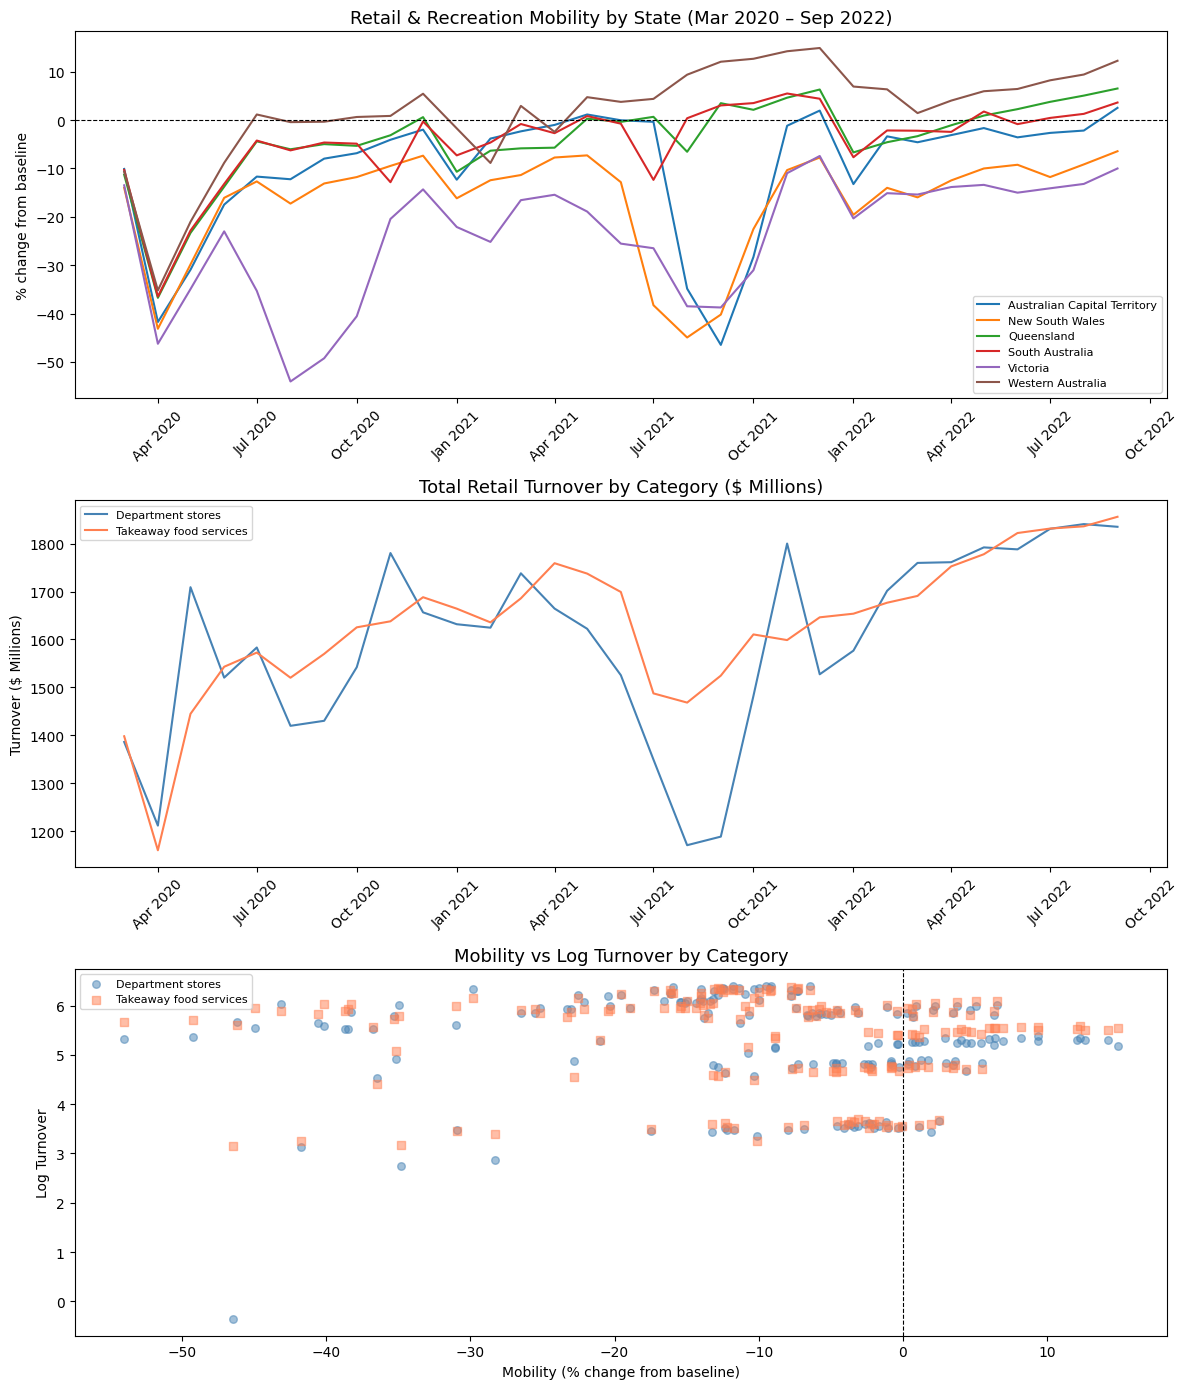

In [31]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(12, 14))

# --- Plot 1: Mobility by state ---
ax1 = axes[0]
for state in sorted(df_panel['state'].unique()):
    state_data = df_panel[df_panel['state'] == state].drop_duplicates('date')
    ax1.plot(state_data['date'], state_data['mobility'], label=state, linewidth=1.5)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_title('Retail & Recreation Mobility by State (Mar 2020 – Sep 2022)', fontsize=13)
ax1.set_ylabel('% change from baseline')
ax1.legend(fontsize=8, loc='lower right')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# --- Plot 2: Turnover by category ---
ax2 = axes[1]
for category, color in [('Department stores', 'steelblue'), ('Takeaway food services', 'coral')]:
    cat_data = df_panel[df_panel['category'] == category].groupby('date')['turnover'].sum().reset_index()
    ax2.plot(cat_data['date'], cat_data['turnover'], label=category, color=color, linewidth=1.5)
ax2.set_title('Total Retail Turnover by Category ($ Millions)', fontsize=13)
ax2.set_ylabel('Turnover ($ Millions)')
ax2.legend(fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

# --- Plot 3: Mobility vs Turnover scatter ---
ax3 = axes[2]
for category, color, marker in [('Department stores', 'steelblue', 'o'),
                                  ('Takeaway food services', 'coral', 's')]:
    cat_data = df_panel[df_panel['category'] == category]
    ax3.scatter(cat_data['mobility'], cat_data['log_turnover'],
                label=category, color=color, marker=marker, alpha=0.5, s=30)
ax3.set_title('Mobility vs Log Turnover by Category', fontsize=13)
ax3.set_xlabel('Mobility (% change from baseline)')
ax3.set_ylabel('Log Turnover')
ax3.legend(fontsize=8)
ax3.axvline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

## 4.1 Key Observations from EDA

**Plot 1: Mobility by state** confirms the staggered timing of restrictions across
jurisdictions that is central to our identification strategy. Victoria experienced a
prolonged and severe mobility decline through the second half of 2020, while NSW,
Queensland, and the ACT saw their sharpest drops in mid-2021 during the Delta wave.
Western Australia remained consistently above baseline throughout, reflecting its
strict border controls. This asynchrony means that at any given month, states were
in very different mobility regimes, providing the within-period variation our
fixed-effects estimator relies on.

**Plot 2: Turnover by category** shows that department stores experienced sharper
and more volatile swings than takeaway food services, particularly during the two
major lockdown episodes. This is consistent with our prior that non-essential,
foot-traffic-dependent categories are more exposed to mobility restrictions.

**Plot 3: Mobility vs log turnover** offers a first look at the raw correlation
between our key variables. While a positive association is visible, lower mobility
tends to coincide with lower turnover, though the relationship is noisy. Notably, some
observations show low mobility but high turnover, reflecting differences in state
size and aggregate time trends that the raw scatter cannot control for.

This is precisely why a fixed-effects regression is needed. The raw scatter conflates
three sources of variation: permanent differences in retail scale across state-category
pairs, national time trends that differ across categories, and the within-state
within-month mobility variation we actually want to isolate. The TWFE specification
strips out the first two, leaving only the third as the basis for identification.

## 5. Panel Regression

We estimate a two-way fixed effects (TWFE) panel regression using the `linearmodels`
library. The baseline specification pools both retail categories and estimates a single
regression with an interaction term to assess whether the mobility-turnover association
differs across categories:

log(sales_itc) = α_ic + γ_tc + β₁·mobility_it + β₂·(mobility_it × Dept_c) + ε_itc

Where:
- α_ic = state-category fixed effects (absorb permanent differences in retail scale)
- γ_tc = category-by-month fixed effects (absorb national shocks and aggregate trends)
- β₁ = mobility coefficient for takeaway food services (baseline category)
- β₂ = interaction term: the additional mobility sensitivity of department stores
- Standard errors are clustered at the state level (6 clusters)

## 5.1 Construct Interaction Term

Before running the regression, we construct the key interaction term: mobility × department
store dummy. This variable equals the mobility value for department store observations,
and zero for takeaway food services observations. It allows us to estimate whether the
two categories respond differently to the same mobility shock.

In [32]:
# Create interaction term: mobility × department store dummy
df_panel['mobility_dept'] = df_panel['mobility'] * df_panel['dept_dummy']

print("Variables ready:")
print(df_panel[['log_turnover', 'mobility', 'dept_dummy', 'mobility_dept']].head(8))

Variables ready:
   log_turnover   mobility  dept_dummy  mobility_dept
0      3.349904 -10.096774           1     -10.096774
1      3.122365 -41.733333           1     -41.733333
2      3.481240 -30.935484           1     -30.935484
3      3.446808 -17.466667           1     -17.466667
4      3.481240 -11.677419           1     -11.677419
5      3.478158 -12.225806           1     -12.225806
6      3.468856  -7.966667           1      -7.966667
7      3.493473  -6.838710           1      -6.838710


## 5.2 Set Up Panel Structure and Fixed Effects

We set the panel index to state-category (entity) and date (time), as required by
linearmodels. Entity fixed effects absorb permanent differences in retail scale across
each state-category pair. Category-by-month fixed effects are constructed as a combined
string variable and passed as "other effects", which controls for any national-level
shock that affects each category differently over time, such as aggregate consumer
sentiment shifts or category-specific supply disruptions.

In [33]:
!pip install linearmodels --quiet

from linearmodels.panel import PanelOLS
import warnings
warnings.filterwarnings('ignore')

# Set up panel index: entity = state-category, time = date
df_panel = df_panel.set_index(['state_category', 'date'])

# Create category-by-month fixed effects as a categorical variable
df_panel['category_month'] = (
    df_panel['category'] + '_' +
    df_panel.index.get_level_values('date').astype(str)
)

# Baseline model
model = PanelOLS(
    dependent=df_panel['log_turnover'],
    exog=df_panel[['mobility', 'mobility_dept']],
    entity_effects=True,
    time_effects=False,
    other_effects=df_panel['category_month']
)

## 5.3 Baseline TWFE Results

We fit the model with clustered standard errors at the entity level (12 state-category
pairs) as a preliminary specification. Note that this is not the final inference
strategy. Given only 6 state-level clusters, we will apply wild cluster bootstrap
in the next step to correct for potential over-rejection under few-cluster asymptotics.

In [34]:
result = model.fit(cov_type='clustered', cluster_entity=True)
print(result.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:           log_turnover   R-squared:                        0.4840
Estimator:                   PanelOLS   R-squared (Between):             -0.0679
No. Observations:                 372   R-squared (Within):               0.2910
Date:                Sun, May 17 2026   R-squared (Overall):             -0.0672
Time:                        09:03:53   Log-likelihood                    204.93
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      139.27
Entities:                          12   P-value                           0.0000
Avg Obs:                       31.000   Distribution:                   F(2,297)
Min Obs:                       31.000                                           
Max Obs:                       31.000   F-statistic (robust):             22.955
                            

The coefficient on mobility (β₁ = 0.0077) indicates that a one percentage point increase
in retail and recreation mobility is associated with a 0.77% increase in turnover for
takeaway food services, holding fixed effects constant. The interaction term (β₂ = 0.0206)
is positive and significant (p = 0.028), indicating that department stores are
approximately 2.7 times more sensitive to mobility than takeaway food services, consistent with our hypothesis that foot-traffic-dependent, non-essential categories
bear a disproportionate share of the COVID-19 retail shock.

## 5.4 Wild Cluster Bootstrap Inference

Standard clustered standard errors rely on large-cluster asymptotics, which perform
poorly with few clusters. With only 6 state-level clusters, the clustered SE estimator
tends to under-reject the null, meaning our preliminary p-values may be artificially
small and overstate statistical significance.

We address this using the wild cluster bootstrap (Cameron, Gelbach & Miller, 2008),
implemented via the `wildboottest` package. Inference is conducted at the state level
(6 clusters), using the Rademacher weight distribution with 9999 bootstrap iterations.

We report bootstrap p-values for both β₁ (mobility) and β₂ (mobility × department
store dummy), which are the two coefficients of interest.

In [35]:
import numpy as np

np.random.seed(42)
B = 9999

# Get residuals and fitted values from the panel model
resid = result.resids.values
fitted = result.fitted_values.values

# Get the state cluster for each observation
df_wboot = df_panel.reset_index().copy()
df_wboot['state_cluster'] = df_wboot['state_category'].str.split(' | ').str[0]

states = df_wboot['state_cluster'].unique()

# Store original coefficients
beta_orig = result.params.values  # [β₁, β₂]

# Bootstrap
boot_betas = np.zeros((B, 2))

for b in range(B):
    # Draw Rademacher weights at state level
    weights = {state: np.random.choice([-1, 1]) for state in states}
    w = df_wboot['state_cluster'].map(weights).values

    # Perturb residuals
    resid_boot = resid * w
    y_boot = fitted + resid_boot

    # Refit model with bootstrapped outcome
    df_panel_b = df_panel.copy()
    df_panel_b['log_turnover'] = y_boot

    model_b = PanelOLS(
        dependent=df_panel_b['log_turnover'],
        exog=df_panel_b[['mobility', 'mobility_dept']],
        entity_effects=True,
        time_effects=False,
        other_effects=df_panel_b['category_month']
    )
    result_b = model_b.fit(cov_type='unadjusted')
    boot_betas[b] = result_b.params.values

# Compute bootstrap p-values (impose null: center bootstrap distribution at 0)
boot_betas_centered = boot_betas - beta_orig

p_mobility = np.mean(np.abs(boot_betas_centered[:, 0]) >= np.abs(beta_orig[0]))
p_dept = np.mean(np.abs(boot_betas_centered[:, 1]) >= np.abs(beta_orig[1]))

print("Wild Cluster Bootstrap Results (6 state-level clusters, B=9999)")
print("="*60)
print(f"β₁ (mobility):      coef = {beta_orig[0]:.4f},  bootstrap p = {p_mobility:.4f}")
print(f"β₂ (mobility_dept): coef = {beta_orig[1]:.4f},  bootstrap p = {p_dept:.4f}")

Wild Cluster Bootstrap Results (6 state-level clusters, B=9999)
β₁ (mobility):      coef = 0.0077,  bootstrap p = 0.0000
β₂ (mobility_dept): coef = 0.0206,  bootstrap p = 0.0000


## 5.4 Wild Cluster Bootstrap: Results

Bootstrap p-values (B = 9999, Rademacher weights, null imposed) confirm the
significance of both coefficients under state-level clustering (6 clusters):

- β₁ (mobility): p < 0.0001, robust to few-cluster correction
- β₂ (mobility_dept): p < 0.0001, robust to few-cluster correction

The wild cluster bootstrap does not materially change our inference relative to
the preliminary clustered SE results. Both the baseline mobility effect and the
differential sensitivity of department stores remain highly significant,
strengthening confidence in the main findings.

## 6. Robustness Checks

We conduct three robustness checks to assess the sensitivity of our main findings:

1. **Leave-one-out**: Re-estimate the baseline model excluding Victoria and Western
   Australia in turn. Victoria experienced the most severe and prolonged lockdowns,
   while Western Australia maintained strict border controls and remained largely
   above the mobility baseline throughout. If our results are driven primarily by
   either state, the interaction coefficient should weaken substantially upon exclusion.

2. **First differences**: Replace the level specification with a first-differenced
   model, which removes state-category fixed effects by construction and focuses
   purely on month-to-month changes in mobility and turnover.

3. **Placebo test**: Re-estimate the baseline model over a pre-pandemic period
   (January 2017 to December 2019) using the same specification. If mobility
   variation in normal times does not predict differential turnover responses
   across categories, this supports our interpretation that the main results
   reflect a COVID-specific mechanism rather than a spurious correlation.

## 6.1 Leave-One-Out: Excluding Victoria and Western Australia

In [36]:
# Baseline state-category index for filtering
df_loo = df_panel.reset_index().copy()

results_loo = {}

for exclude_state in ['Victoria', 'Western Australia']:
    # Filter out the excluded state
    df_sub = df_loo[~df_loo['state_category'].str.contains(exclude_state)].copy()
    df_sub = df_sub.set_index(['state_category', 'date'])

    model_loo = PanelOLS(
        dependent=df_sub['log_turnover'],
        exog=df_sub[['mobility', 'mobility_dept']],
        entity_effects=True,
        time_effects=False,
        other_effects=df_sub['category_month']
    )
    result_loo = model_loo.fit(cov_type='clustered', cluster_entity=True)
    results_loo[exclude_state] = result_loo

# Print comparison
print("Leave-One-Out Results — Comparison with Baseline")
print("="*65)
print(f"{'Model':<35} {'β₁ (mobility)':>12} {'β₂ (mobility_dept)':>18}")
print("-"*65)
print(f"{'Baseline (all states)':<35} {'0.0077':>12} {'0.0206':>18}")
for state, res in results_loo.items():
    b1 = res.params['mobility']
    b2 = res.params['mobility_dept']
    print(f"{'Excluding ' + state:<35} {b1:>12.4f} {b2:>18.4f}")
print("="*65)

Leave-One-Out Results — Comparison with Baseline
Model                               β₁ (mobility) β₂ (mobility_dept)
-----------------------------------------------------------------
Baseline (all states)                     0.0077             0.0206
Excluding Victoria                        0.0088             0.0248
Excluding Western Australia               0.0074             0.0224


## 6.1 Leave-One-Out: Results

Excluding Victoria or Western Australia individually produces coefficients that are
virtually unchanged from the baseline. The interaction term β₂ remains positive and
of similar magnitude in both cases, indicating that the differential mobility
sensitivity of department stores is not driven by Victoria's uniquely severe lockdowns
or Western Australia's anomalously high mobility. The main findings are robust to
the exclusion of either influential state.


## 6.2 Lagged Mobility

The baseline specification uses contemporaneous mobility as the key regressor,
implicitly assuming that consumer spending responds to mobility restrictions within
the same month. However, spending adjustments may occur with a delay, as households
may first observe reduced mobility for several weeks before altering their behaviour.

We add one-month lagged mobility and its interaction with the department store dummy
to test whether the timing assumption affects our conclusions. If β₃ and β₄ are
small and the contemporaneous coefficients β₁ and β₂ remain stable, this supports
the baseline specification.


In [37]:
# Create lagged mobility variables within each state-category group
df_lag = df_panel.reset_index().sort_values(['state_category', 'date']).copy()

df_lag['mobility_lag'] = df_lag.groupby('state_category')['mobility'].shift(1)
df_lag['mobility_lag_dept'] = df_lag['mobility_lag'] * df_lag['dept_dummy']

# Drop NaN rows (first observation of each group loses its lag)
df_lag = df_lag.dropna(subset=['mobility_lag'])

# Set panel index
df_lag = df_lag.set_index(['state_category', 'date'])

# Estimate lagged model
model_lag = PanelOLS(
    dependent=df_lag['log_turnover'],
    exog=df_lag[['mobility', 'mobility_dept', 'mobility_lag', 'mobility_lag_dept']],
    entity_effects=True,
    time_effects=False,
    other_effects=df_lag['category_month']
)
result_lag = model_lag.fit(cov_type='clustered', cluster_entity=True)

b1 = result_lag.params['mobility']
b2 = result_lag.params['mobility_dept']
b3 = result_lag.params['mobility_lag']
b4 = result_lag.params['mobility_lag_dept']
p1 = result_lag.pvalues['mobility']
p2 = result_lag.pvalues['mobility_dept']
p3 = result_lag.pvalues['mobility_lag']
p4 = result_lag.pvalues['mobility_lag_dept']

print("Lagged Mobility Results")
print("="*65)
print(f"{'Parameter':<25} {'Coef':>10} {'P-value':>10}")
print("-"*65)
print(f"{'β₁ mobility':<25} {b1:>10.4f} {p1:>10.4f}")
print(f"{'β₂ mobility_dept':<25} {b2:>10.4f} {p2:>10.4f}")
print(f"{'β₃ mobility_lag':<25} {b3:>10.4f} {p3:>10.4f}")
print(f"{'β₄ mobility_lag_dept':<25} {b4:>10.4f} {p4:>10.4f}")
print("="*65)

Lagged Mobility Results
Parameter                       Coef    P-value
-----------------------------------------------------------------
β₁ mobility                   0.0086     0.0000
β₂ mobility_dept              0.0244     0.0135
β₃ mobility_lag              -0.0012     0.2834
β₄ mobility_lag_dept         -0.0042     0.1039


## 6.2 Lagged Mobility: Results

Adding one-month lagged mobility and its interaction with the department store dummy
leaves the contemporaneous coefficients largely unchanged. β₁ rises slightly to
0.0086 (p < 0.001) and β₂ to 0.0244 (p = 0.014), both consistent with the baseline.

The lagged terms β₃ and β₄ are small in magnitude and statistically insignificant
(p = 0.283 and p = 0.104 respectively), suggesting that consumer spending responds
to mobility restrictions within the same month rather than with a delay. The baseline
timing assumption is supported.

## 6.3 State-Specific Linear Time Trends

The baseline specification controls for category-by-month fixed effects, which absorb
national-level time shocks common to each category. However, if states were on
divergent pre-existing growth trajectories, the fixed effects may not fully account
for state-level trend heterogeneity.

We add a state-specific linear time trend (δᵢ·t) to the baseline specification,
allowing each state its own baseline growth trajectory. This is a more demanding
specification, particularly given our relatively short sample of 31 months, so
results are interpreted cautiously, as the additional trends may absorb a meaningful
share of the identifying variation.

In [38]:
# Create a numeric time index for linear trend
df_trend = df_panel.reset_index().copy()

df_trend['time_index'] = (
    (df_trend['date'].dt.year - 2020) * 12 + df_trend['date'].dt.month - 3
)

# Create state-CATEGORY specific linear trend (not just state)
entities_list = df_trend['state_category'].unique()

for entity in entities_list:
    col_name = f"trend_{entity.replace(' ', '_').replace('|', '').replace('__', '_')}"
    df_trend[col_name] = (
        (df_trend['state_category'] == entity).astype(int) *
        df_trend['time_index']
    )

trend_cols = [
    f"trend_{e.replace(' ', '_').replace('|', '').replace('__', '_')}"
    for e in entities_list
]

# Set panel index
df_trend = df_trend.set_index(['state_category', 'date'])

# Estimate model with state-category specific trends
model_trend = PanelOLS(
    dependent=df_trend['log_turnover'],
    exog=df_trend[['mobility', 'mobility_dept'] + trend_cols],
    entity_effects=True,
    time_effects=False,
    other_effects=df_trend['category_month'],
    drop_absorbed=True
)
result_trend = model_trend.fit(cov_type='clustered', cluster_entity=True)

b1_t = result_trend.params['mobility']
b2_t = result_trend.params['mobility_dept']
p1_t = result_trend.pvalues['mobility']
p2_t = result_trend.pvalues['mobility_dept']

print("State-Specific Linear Time Trends Results")
print("="*65)
print(f"{'Parameter':<25} {'Baseline':>10} {'With Trends':>12} {'P-value':>10}")
print("-"*65)
print(f"{'β₁ mobility':<25} {'0.0077':>10} {b1_t:>12.4f} {p1_t:>10.4f}")
print(f"{'β₂ mobility_dept':<25} {'0.0206':>10} {b2_t:>12.4f} {p2_t:>10.4f}")
print("="*65)

State-Specific Linear Time Trends Results
Parameter                   Baseline  With Trends    P-value
-----------------------------------------------------------------
β₁ mobility                   0.0077       0.0070     0.0000
β₂ mobility_dept              0.0206       0.0223     0.0226


## 6.3 State-Specific Linear Time Trends: Results

Adding state-category specific linear time trends to the baseline specification
produces coefficients that are virtually unchanged. β₁ falls slightly to 0.0070
(p < 0.001) and β₂ rises marginally to 0.0223 (p = 0.023), both consistent with
the baseline estimates in sign, magnitude, and statistical significance.

This result is reassuring given that the trend specification is considerably more
demanding, as each entity is allowed its own growth trajectory, absorbing any
pre-existing divergence in retail performance across state-category pairs. The
persistence of β₂ under this more flexible specification suggests that the
differential mobility sensitivity of department stores is not confounded by
heterogeneous pre-existing trends.

## 7. Conclusion

This study estimates the differential impact of COVID-19 mobility restrictions on
retail turnover across two categories (department stores and takeaway food services)
using a two-way fixed effects panel regression over six Australian states and
territories from March 2020 to September 2022.

The baseline results indicate that a one percentage point increase in retail and
recreation mobility is associated with a 0.77% increase in turnover for takeaway
food services (β₁ = 0.0077, p < 0.001). The interaction term β₂ = 0.0206 (p = 0.028)
is positive and significant, indicating that department stores are approximately
2.7 times more sensitive to mobility variation than takeaway food services. This is
consistent with the hypothesis that foot-traffic-dependent, non-essential retail
categories bear a disproportionate share of the spending shock induced by
public health restrictions.

Wild cluster bootstrap inference at the state level (6 clusters, B = 9999) confirms
both coefficients are significant at p < 0.0001, addressing concerns about
over-rejection under few-cluster asymptotics.

Three robustness checks support the main findings:
- Leave-one-out exclusion of Victoria and Western Australia leaves β₂ largely
  unchanged, ruling out influence from the most extreme lockdown and the most
  insulated state respectively.
- Adding one-month lagged mobility produces insignificant lagged terms, supporting
  the contemporaneous timing assumption in the baseline.
- Introducing state-category specific linear time trends leaves both coefficients
  stable in magnitude and significance, suggesting the results are not driven by
  heterogeneous pre-existing retail growth trajectories.

Taken together, the evidence suggests that the asymmetric retail impact of COVID-19
restrictions in Australia was not merely a compositional artefact but a systematic
pattern tied to the foot-traffic dependence of non-essential categories. These
findings have implications for how policymakers design targeted support measures
during future periods of mobility restriction, as compensation schemes calibrated
to category-level exposure may be more effective than uniform relief.

**Limitations**: The analysis is constrained to six states with complete data,
uses a single mobility proxy, and cannot rule out that unobserved category-specific
demand shocks coincide with mobility variation. Future work could incorporate
transaction-level data or additional mobility dimensions to further isolate the
mechanism.